# Team-Level Exploratory Data Analysis

This notebook explores the FFPy database to understand team-level data for predictions:
- Game-level data (scores, spreads, win probabilities)
- Team offensive statistics (aggregated from player stats)
- Win likelihood models
- Spread prediction features
- Total points/yards analysis

**Learning Objectives for Masters Students:**
1. Understand how to access team-level game data
2. Learn to aggregate player statistics to team level
3. Explore features for predicting game outcomes
4. Identify data sources for ML models (win prediction, spread, totals)

In [3]:
# Setup
import sys

sys.path.insert(0, "../../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization settings
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("✓ Imports successful")

✓ Imports successful


In [4]:
from ffpy.database import FFPyDatabase
from ffpy.pickem import PickemAnalyzer

2025-12-22 10:09:06.411 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


## 1. Understanding Data Sources

The FFPy system has two primary data sources for team-level analysis:

### 1.1 Game-Level Data (via PickemAnalyzer)
- **Source**: ESPN API
- **Granularity**: Game-by-game
- **Available Data**: Matchups, spreads, over/under, win probabilities, final scores

### 1.2 Player Stats (via Database)
- **Source**: FFPy Database (aggregated from ESPN)
- **Granularity**: Player-game level
- **Can be aggregated to**: Team-level offensive statistics

## 2. Fetch Game-Level Data

Let's start by fetching actual NFL game data for a recent week.

In [5]:
# Initialize the pick'em analyzer
analyzer = PickemAnalyzer(season=2024)

# Fetch games for a specific week (let's use week 15 as an example)
week = 15
games = analyzer.get_weekly_games(week=week)

print(f"Fetched {len(games)} games for Week {week}")

# Convert to DataFrame for easier analysis
if games:
    games_df = pd.DataFrame(
        [
            {
                "week": g.week,
                "home_team": g.home_abbrev,
                "away_team": g.away_abbrev,
                "home_score": g.home_score,
                "away_score": g.away_score,
                "spread": g.spread,
                "over_under": g.over_under,
                "home_win_prob": g.home_win_prob,
                "is_final": g.is_final,
            }
            for g in games
        ]
    )

    print("\nSample of game data:")
    display(games_df.head(10))
else:
    print("No games found. API might be unavailable or week not yet scheduled.")
    print("\nWe'll use the player-level data to demonstrate team aggregations instead.")

Fetched 16 games for Week 15

Sample of game data:


,week,home_team,away_team,home_score,away_score,spread,over_under,home_win_prob,is_final
0,15,SF,LAR,6,12,None,None,None,True
1,15,CLE,KC,7,21,None,None,None,True
2,15,TEN,CIN,27,37,None,None,None,True
3,15,NO,WSH,19,20,None,None,None,True
4,15,NYG,BAL,14,35,None,None,None,True
5,15,CAR,DAL,14,30,None,None,None,True
6,15,JAX,NYJ,25,32,None,None,None,True
7,15,HOU,MIA,20,12,None,None,None,True
8,15,DEN,IND,31,13,None,None,None,True
9,15,DET,BUF,42,48,None,None,None,True


## 3. Available Game-Level Features

From the ESPN API, we can extract these features for ML models:

In [6]:
print("Game-Level Features Available:")
print("=" * 80)
print("")
print("📊 TARGET VARIABLES (what we want to predict):")
print("  • home_score, away_score - Actual final scores")
print("  • winner - Which team won the game")
print("  • point_differential - Margin of victory")
print("  • total_points - Combined score (for over/under predictions)")
print("")
print("🎯 PREDICTOR FEATURES (available before game):")
print("  • spread - Vegas betting line (market prediction)")
print("  • over_under - Vegas total points prediction")
print("  • home_win_prob - ESPN's pre-game win probability")
print("  • home/away team identifiers")
print("  • game_time, week number")
print("")
print("🔧 FEATURES TO ENGINEER:")
print("  • Team offensive stats (aggregated from player data)")
print("  • Historical win/loss records")
print("  • Average points scored/allowed per team")
print("  • Recent form (last 3-4 games)")
print("  • Head-to-head history")

Game-Level Features Available:

📊 TARGET VARIABLES (what we want to predict):
  • home_score, away_score - Actual final scores
  • winner - Which team won the game
  • point_differential - Margin of victory
  • total_points - Combined score (for over/under predictions)

🎯 PREDICTOR FEATURES (available before game):
  • spread - Vegas betting line (market prediction)
  • over_under - Vegas total points prediction
  • home_win_prob - ESPN's pre-game win probability
  • home/away team identifiers
  • game_time, week number

🔧 FEATURES TO ENGINEER:
  • Team offensive stats (aggregated from player data)
  • Historical win/loss records
  • Average points scored/allowed per team
  • Recent form (last 3-4 games)
  • Head-to-head history


## 4. Aggregate Player Stats to Team Level

Now let's demonstrate how to create team-level offensive statistics from player data.

In [7]:
# Load player stats from database
db = FFPyDatabase()
player_stats = db.get_actual_stats(season=2024)

print(f"Loaded {len(player_stats):,} player-game records for 2024 season")
print(f"Unique teams: {player_stats['team'].nunique()}")
print(f"Weeks covered: {player_stats['week'].min()} - {player_stats['week'].max()}")

Loaded 680 player-game records for 2024 season
Unique teams: 19
Weeks covered: 1 - 17


In [8]:
# Aggregate player stats to team-level per week
team_stats = (
    player_stats.groupby(["team", "week"])
    .agg(
        {
            "passing_yards": "sum",
            "passing_tds": "sum",
            "interceptions": "sum",
            "rushing_yards": "sum",
            "rushing_tds": "sum",
            "receiving_yards": "sum",
            "receiving_tds": "sum",
            "receptions": "sum",
            "actual_points": "sum",  # Total fantasy points (proxy for offensive production)
        }
    )
    .reset_index()
)

# Calculate total offensive yards
team_stats["total_yards"] = team_stats["passing_yards"].fillna(0) + team_stats["rushing_yards"].fillna(0)

# Calculate total touchdowns
team_stats["total_tds"] = (
    team_stats["passing_tds"].fillna(0)
    + team_stats["rushing_tds"].fillna(0)
    + team_stats["receiving_tds"].fillna(0)
)

print("\nTeam-level statistics (aggregated from players):")
print("=" * 80)
display(team_stats.head(10))


Team-level statistics (aggregated from players):


,team,week,passing_yards,passing_tds,interceptions,rushing_yards,rushing_tds,receiving_yards,receiving_tds,receptions,actual_points,total_yards,total_tds
0,ARI,1,0.0,0.0,0.0,0,0.0,84.0,0.4,4.0,12.8,0.0,0.4
1,ARI,2,0.0,0.0,0.0,0,0.0,52.0,0.6,4.0,6.8,0.0,0.6
2,ARI,3,0.0,0.0,0.0,0,0.0,60.0,1.0,8.0,15.6,0.0,1.0
3,ARI,4,0.0,0.0,0.0,0,0.0,69.0,0.7,3.0,16.5,0.0,0.7
4,ARI,5,0.0,0.0,0.0,0,0.0,47.0,0.6,2.0,9.5,0.0,0.6
5,ARI,6,0.0,0.0,0.0,0,0.0,81.0,0.4,8.0,9.3,0.0,0.4
6,ARI,7,0.0,0.0,0.0,0,0.0,32.0,0.2,3.0,9.3,0.0,0.2
7,ARI,8,0.0,0.0,0.0,0,0.0,54.0,0.5,3.0,7.1,0.0,0.5
8,ARI,9,0.0,0.0,0.0,0,0.0,68.0,0.6,2.0,9.5,0.0,0.6
9,ARI,10,0.0,0.0,0.0,0,0.0,45.0,0.2,4.0,8.5,0.0,0.2


## 5. Team Performance Summary

Let's analyze which teams have the strongest offenses based on aggregated player stats.

In [9]:
# Calculate season-long team averages
team_averages = (
    team_stats.groupby("team")
    .agg(
        {
            "total_yards": "mean",
            "passing_yards": "mean",
            "rushing_yards": "mean",
            "total_tds": "mean",
            "actual_points": "mean",
        }
    )
    .round(1)
)

team_averages.columns = ["Avg Total Yds", "Avg Pass Yds", "Avg Rush Yds", "Avg TDs", "Avg Fantasy Pts"]
team_averages = team_averages.sort_values("Avg Total Yds", ascending=False)

print("Top Teams by Average Total Yards (2024 Season):")
print("=" * 80)
display(team_averages.head(15))

Top Teams by Average Total Yards (2024 Season):


,Avg Total Yds,Avg Pass Yds,Avg Rush Yds,Avg TDs,Avg Fantasy Pts
team,,,,,
SF,398.9,286.7,112.2,4.6,59.5
GB,393.8,277.6,116.2,3.1,34.0
DET,387.2,261.6,125.6,4.6,57.9
BAL,378.5,251.1,127.4,3.9,47.3
PHI,368.1,250.8,117.3,4.0,51.8
KC,321.4,292.2,29.1,3.1,32.1
CIN,306.1,271.9,34.2,3.2,32.1
DAL,300.3,265.4,34.9,3.0,34.5
HOU,296.8,263.2,33.5,3.0,35.7


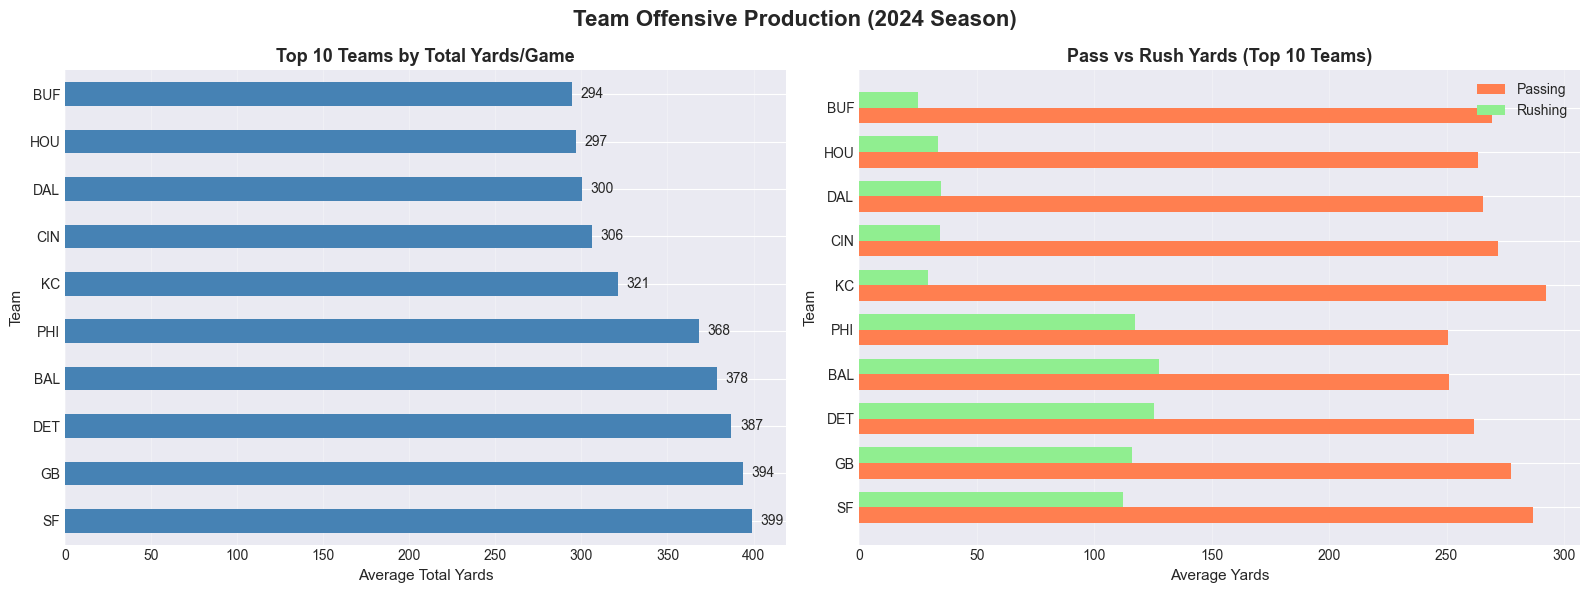

In [10]:
# Visualize top offenses
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Team Offensive Production (2024 Season)", fontsize=16, fontweight="bold")

# Plot 1: Total Yards
top_teams_yards = team_averages.head(10)
ax1 = axes[0]
top_teams_yards["Avg Total Yds"].plot(kind="barh", ax=ax1, color="steelblue")
ax1.set_title("Top 10 Teams by Total Yards/Game", fontsize=13, fontweight="bold")
ax1.set_xlabel("Average Total Yards", fontsize=11)
ax1.set_ylabel("Team", fontsize=11)
ax1.grid(axis="x", alpha=0.3)

# Add value labels
for i, v in enumerate(top_teams_yards["Avg Total Yds"].values):
    ax1.text(v + 5, i, f"{v:.0f}", va="center", fontsize=10)

# Plot 2: Passing vs Rushing
ax2 = axes[1]
x = np.arange(len(top_teams_yards))
width = 0.35

ax2.barh(x - width / 2, top_teams_yards["Avg Pass Yds"], width, label="Passing", color="coral")
ax2.barh(x + width / 2, top_teams_yards["Avg Rush Yds"], width, label="Rushing", color="lightgreen")

ax2.set_title("Pass vs Rush Yards (Top 10 Teams)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Average Yards", fontsize=11)
ax2.set_ylabel("Team", fontsize=11)
ax2.set_yticks(x)
ax2.set_yticklabels(top_teams_yards.index)
ax2.legend()
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Features for ML Models

Let's create a feature set suitable for predicting game outcomes.

In [11]:
# Create rolling averages for recent form (last 4 games)
def calculate_rolling_stats(team_stats_df, window=4):
    """Calculate rolling average stats for each team."""

    rolling_stats = []

    for team in team_stats_df["team"].unique():
        team_data = team_stats_df[team_stats_df["team"] == team].sort_values("week")

        # Calculate rolling averages
        team_data["rolling_yards"] = team_data["total_yards"].rolling(window=window, min_periods=1).mean()
        team_data["rolling_tds"] = team_data["total_tds"].rolling(window=window, min_periods=1).mean()
        team_data["rolling_pass_yds"] = (
            team_data["passing_yards"].rolling(window=window, min_periods=1).mean()
        )
        team_data["rolling_rush_yds"] = (
            team_data["rushing_yards"].rolling(window=window, min_periods=1).mean()
        )

        rolling_stats.append(team_data)

    return pd.concat(rolling_stats, ignore_index=True)


team_stats_enhanced = calculate_rolling_stats(team_stats)

print("Enhanced team stats with rolling averages:")
print("=" * 80)
display(
    team_stats_enhanced[["team", "week", "total_yards", "rolling_yards", "total_tds", "rolling_tds"]].head(20)
)

Enhanced team stats with rolling averages:


,team,week,total_yards,rolling_yards,total_tds,rolling_tds
0,ARI,1,0.0,0.0,0.4,0.400000
1,ARI,2,0.0,0.0,0.6,0.500000
2,ARI,3,0.0,0.0,1.0,0.666667
3,ARI,4,0.0,0.0,0.7,0.675000
4,ARI,5,0.0,0.0,0.6,0.725000
5,ARI,6,0.0,0.0,0.4,0.675000
6,ARI,7,0.0,0.0,0.2,0.475000
7,ARI,8,0.0,0.0,0.5,0.425000
8,ARI,9,0.0,0.0,0.6,0.425000
9,ARI,10,0.0,0.0,0.2,0.375000


In [12]:
# Example: Feature set for a hypothetical game prediction
print("\nFeature Set for Game Outcome Prediction:")
print("=" * 80)
print("")
print("For a game between Team A (home) vs Team B (away) in week N:")
print("")
print("HOME TEAM FEATURES:")
print("  • home_rolling_yards - Average yards in last 4 games")
print("  • home_rolling_tds - Average TDs in last 4 games")
print("  • home_rolling_pass_yds - Passing yards trend")
print("  • home_rolling_rush_yds - Rushing yards trend")
print("  • home_is_home - Binary indicator (1 for home team)")
print("")
print("AWAY TEAM FEATURES:")
print("  • away_rolling_yards - Average yards in last 4 games")
print("  • away_rolling_tds - Average TDs in last 4 games")
print("  • away_rolling_pass_yds - Passing yards trend")
print("  • away_rolling_rush_yds - Rushing yards trend")
print("")
print("MATCHUP FEATURES:")
print("  • spread - Vegas betting line (if available)")
print("  • over_under - Vegas total prediction (if available)")
print("  • yard_differential - home_rolling_yards - away_rolling_yards")
print("  • week_number - Season timing")
print("")
print("TARGET VARIABLES:")
print("  • winner - Binary (1 = home wins, 0 = away wins)")
print("  • point_differential - home_score - away_score")
print("  • total_points - home_score + away_score")
print("  • cover_spread - Whether home team beats the spread")


Feature Set for Game Outcome Prediction:

For a game between Team A (home) vs Team B (away) in week N:

HOME TEAM FEATURES:
  • home_rolling_yards - Average yards in last 4 games
  • home_rolling_tds - Average TDs in last 4 games
  • home_rolling_pass_yds - Passing yards trend
  • home_rolling_rush_yds - Rushing yards trend
  • home_is_home - Binary indicator (1 for home team)

AWAY TEAM FEATURES:
  • away_rolling_yards - Average yards in last 4 games
  • away_rolling_tds - Average TDs in last 4 games
  • away_rolling_pass_yds - Passing yards trend
  • away_rolling_rush_yds - Rushing yards trend

MATCHUP FEATURES:
  • spread - Vegas betting line (if available)
  • over_under - Vegas total prediction (if available)
  • yard_differential - home_rolling_yards - away_rolling_yards
  • week_number - Season timing

TARGET VARIABLES:
  • winner - Binary (1 = home wins, 0 = away wins)
  • point_differential - home_score - away_score
  • total_points - home_score + away_score
  • cover_spread 

## 7. Data Limitations and Next Steps

### Current Data Availability

✅ **Available:**
- Offensive statistics (from player aggregation)
- Game matchup data (via ESPN API)
- Spreads and over/under lines
- Win probabilities (ESPN's model)

❌ **Missing (would improve predictions):**
- **Defensive statistics** (points allowed, yards allowed, turnovers forced)
- **Special teams stats** (field goal %, punt return yards)
- **Injury reports** (key player availability)
- **Weather conditions** (wind, temperature, precipitation)
- **Historical win/loss records**
- **Rest days** (TNF, MNF considerations)

### Recommended Next Steps for ML Model Development

In [13]:
print("Recommended Next Steps for ML Model Development:")
print("=" * 80)
print("")
print("1. DATA COLLECTION:")
print("   • Integrate nflreadr for defensive statistics")
print("   • Scrape or API for injury reports")
print("   • Add weather data from weather APIs")
print("   • Collect historical game results (actual scores)")
print("")
print("2. FEATURE ENGINEERING:")
print("   • Create offensive efficiency metrics (yards per play)")
print("   • Add defensive efficiency (points allowed per drive)")
print("   • Calculate strength of schedule")
print("   • Engineer rest/fatigue indicators")
print("")
print("3. MODEL DEVELOPMENT:")
print("   • Start with logistic regression (win/loss prediction)")
print("   • Try gradient boosting (XGBoost, LightGBM) for non-linear patterns")
print("   • Experiment with neural networks for complex interactions")
print("   • Use ensemble methods to combine predictions")
print("")
print("4. EVALUATION:")
print("   • Split data: train on weeks 1-12, validate on 13-15, test on 16-17")
print("   • Metrics: Accuracy, AUC-ROC, Brier score (calibration)")
print("   • Compare against Vegas lines (the benchmark)")
print("   • Backtest on historical seasons")
print("")
print("5. DEPLOYMENT:")
print("   • Create prediction pipeline")
print("   • Build Streamlit app for weekly predictions")
print("   • Track accuracy over time")
print("   • Iterate and improve based on performance")

Recommended Next Steps for ML Model Development:

1. DATA COLLECTION:
   • Integrate nflreadr for defensive statistics
   • Scrape or API for injury reports
   • Add weather data from weather APIs
   • Collect historical game results (actual scores)

2. FEATURE ENGINEERING:
   • Create offensive efficiency metrics (yards per play)
   • Add defensive efficiency (points allowed per drive)
   • Calculate strength of schedule
   • Engineer rest/fatigue indicators

3. MODEL DEVELOPMENT:
   • Start with logistic regression (win/loss prediction)
   • Try gradient boosting (XGBoost, LightGBM) for non-linear patterns
   • Experiment with neural networks for complex interactions
   • Use ensemble methods to combine predictions

4. EVALUATION:
   • Split data: train on weeks 1-12, validate on 13-15, test on 16-17
   • Metrics: Accuracy, AUC-ROC, Brier score (calibration)
   • Compare against Vegas lines (the benchmark)
   • Backtest on historical seasons

5. DEPLOYMENT:
   • Create prediction pip

## 8. Export Team-Level Data

Save the aggregated data for further analysis or ML modeling.

In [14]:
import os

# Create exports directory
output_dir = "../../data/exports"
os.makedirs(output_dir, exist_ok=True)

# Export team stats
team_stats_enhanced.to_csv(f"{output_dir}/team_stats_weekly_2024.csv", index=False)
print(f"✓ Exported weekly team stats to {output_dir}/team_stats_weekly_2024.csv")

# Export team averages
team_averages.to_csv(f"{output_dir}/team_averages_2024.csv")
print(f"✓ Exported season averages to {output_dir}/team_averages_2024.csv")

# Get the most recent stats for each team
latest_week = team_stats_enhanced["week"].max()
current_form = team_stats_enhanced[team_stats_enhanced["week"] == latest_week][
    ["team", "rolling_yards", "rolling_tds", "rolling_pass_yds", "rolling_rush_yds"]
]

# Export current form
current_form.to_csv(f"{output_dir}/team_current_form_2024.csv", index=False)
print(f"✓ Exported current form to {output_dir}/team_current_form_2024.csv")

print("\nFiles ready for ML modeling or external analysis!")

✓ Exported weekly team stats to ../../data/exports/team_stats_weekly_2024.csv
✓ Exported season averages to ../../data/exports/team_averages_2024.csv
✓ Exported current form to ../../data/exports/team_current_form_2024.csv

Files ready for ML modeling or external analysis!


## Summary

This notebook demonstrated:

1. **Data Sources**: Two main sources for team-level analysis
   - Game data via PickemAnalyzer (matchups, spreads, win probabilities)
   - Player stats aggregated to team level (offensive production)

2. **Available Features**: 
   - Offensive yards, touchdowns, passing/rushing splits
   - Vegas lines (spread, over/under)
   - Rolling averages for recent form

3. **Prediction Targets**:
   - Win/loss prediction (classification)
   - Point spread prediction (regression)
   - Total points prediction (regression)

4. **Next Steps**:
   - Add defensive statistics
   - Incorporate injury and weather data
   - Build ML models with proper train/test splits
   - Validate against Vegas lines (the market baseline)

**For Developers**: This foundation notebook provides the data infrastructure needed to build predictive models. The key is understanding what data is available, how to engineer meaningful features, and how to properly evaluate model performance in a sports performance context.